Минькин Александр Дмитриевич - ИКБО-25-22



<h1> Практическая работа №7


<h1> Ансамблевое обучение // Stacking // Bagging // Boosting

1. Найти данные для кластеризации. Данные в группе не должны
повторяться. Если признаки в данных имеют очень сильно разные
масштабы, то необходимо данные предварительно нормализовать.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data_population2023.csv to data_population2023.csv


2) Реализовать баггинг.

Первые 5 строк датасета:
   sr.no.     province division district  households  population_2023  \
0       1  Balochistan    Kalat   Awaran       27808           178958   
1       2  Balochistan    Kalat    Kalat       33415           272506   
2       3  Balochistan    Kalat  Khuzdar      161594           997214   
3       4  Balochistan    Kalat  Lasbela      115635           680977   
4       5  Balochistan    Kalat  Mastung       43736           313271   

   average_household_size  population_2017  growth_rate  area(km²)  ...  \
0                    6.44           121821         6.64      29510  ...   
1                    8.16           211201         4.35       6622  ...   
2                    6.17           798896         3.78      35380  ...   
3                    5.89           576271         2.83      15153  ...   
4                    7.16           265676         2.79       5896  ...   

   primary_girls_schools  secondary_boys_schools  secondary_girls_schools  \
0       

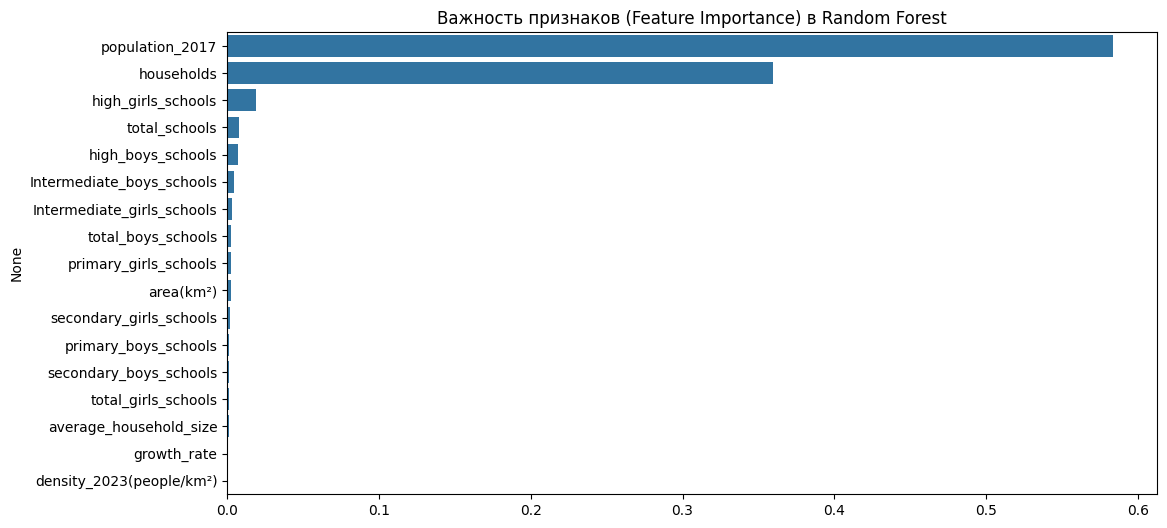

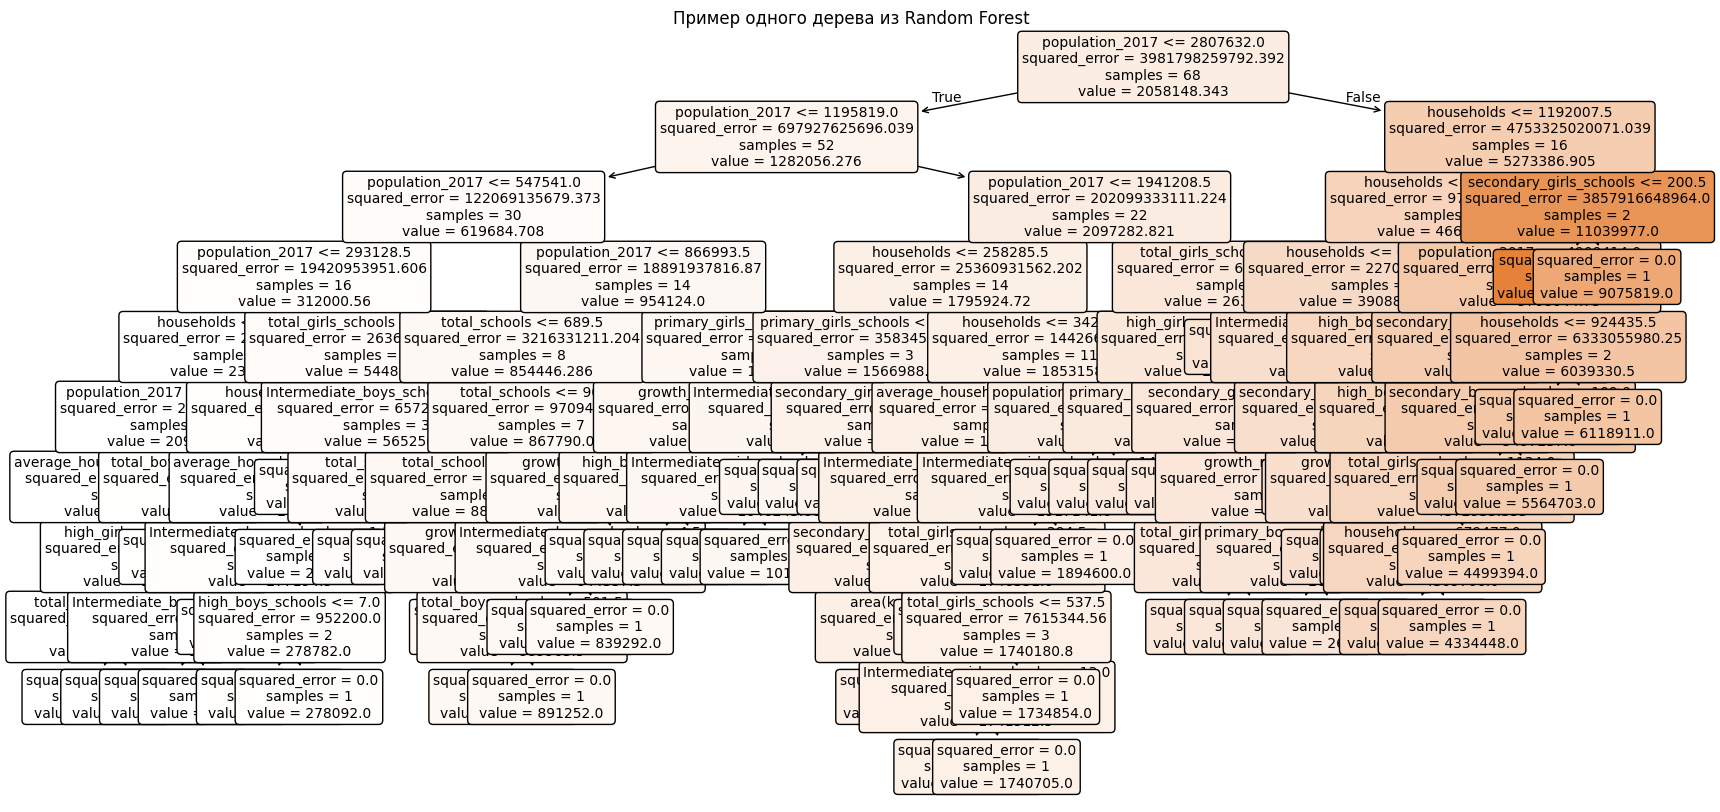

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import seaborn as sns


data = pd.read_csv('/content/data_population2023.csv')


print("Первые 5 строк датасета:")
print(data.head())


features = ['households', 'average_household_size', 'population_2017', 'growth_rate', 'area(km²)',
            'density_2023(people/km²)', 'primary_boys_schools', 'primary_girls_schools',
            'secondary_boys_schools', 'secondary_girls_schools', 'high_boys_schools', 'high_girls_schools',
            'Intermediate_boys_schools', 'Intermediate_girls_schools', 'total_boys_schools', 'total_girls_schools', 'total_schools']

X = data[features]
y = data['population_2023']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42
)


rf_model.fit(X_train, y_train)


y_pred = rf_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'\nMean Squared Error (MSE): {mse:.2f}')
print(f'Коэффициент детерминации (R²): {r2:.2f}')

feature_importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=feature_importances.values, y=feature_importances.index)
plt.title('Важность признаков (Feature Importance) в Random Forest')
plt.show()


tree = rf_model.estimators_[0]

plt.figure(figsize=(20,10))
plot_tree(tree, feature_names=features, filled=True, rounded=True, fontsize=10)
plt.title("Пример одного дерева из Random Forest")
plt.show()

3) Реализовать бустинг на тех же данных, что использовались для баггинга.

In [ ]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score


data = pd.read_csv('/content/data_population2023.csv')
data.head()

features = data.drop(columns=['sr.no.', 'population_2023', 'province', 'division', 'district'])
target = data['population_2023']


X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42
)


rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)


print("Random Forest R^2:", r2_score(y_test, y_pred_rf))
print("Random Forest MSE:", mean_squared_error(y_test, y_pred_rf))

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    min_samples_leaf=5,
    random_state=42
)


gbr.fit(X_train, y_train)


y_pred_gbr = gbr.predict(X_test)


print("Gradient Boosting R^2:", r2_score(y_test, y_pred_gbr))
print("Gradient Boosting MSE:", mean_squared_error(y_test, y_pred_gbr))
print("R^2 Random Forest:", r2_score(y_test, y_pred_rf))
print("R^2 Gradient Boosting:", r2_score(y_test, y_pred_gbr))


Random Forest R^2: 0.9902127230594779
Random Forest MSE: 8824200825.067791
Gradient Boosting R^2: 0.9680482164967752
Gradient Boosting MSE: 28807701678.92102
R^2 Random Forest: 0.9902127230594779
R^2 Gradient Boosting: 0.9680482164967752


4) Сравнить результаты работы алгоритмов (время работы и качество
моделей). Сделать выводы.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import time


data = pd.read_csv("data_population2023.csv")

data.columns = data.columns.str.strip()

print(data.head())
print(data.columns)

features = data.drop(columns=['sr.no.', 'population_2023', 'province', 'division', 'district'])
target = data['population_2023']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42
)

start_time = time.time()
rf.fit(X_train, y_train)
rf_time = time.time() - start_time

y_pred_rf = rf.predict(X_test)

rf_r2 = r2_score(y_test, y_pred_rf)
rf_mse = mean_squared_error(y_test, y_pred_rf)

print(f"Random Forest: R^2 = {rf_r2:.4f}, MSE = {rf_mse:.2f}, Время = {rf_time:.2f} сек")

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    min_samples_leaf=5,
    random_state=42
)

start_time = time.time()
gbr.fit(X_train_scaled, y_train)
gbr_time = time.time() - start_time

y_pred_gbr = gbr.predict(X_test_scaled)

gbr_r2 = r2_score(y_test, y_pred_gbr)
gbr_mse = mean_squared_error(y_test, y_pred_gbr)

print(f"Gradient Boosting: R^2 = {gbr_r2:.4f}, MSE = {gbr_mse:.2f}, Время = {gbr_time:.2f} сек")

comparison = pd.DataFrame({
    'Модель': ['Random Forest (Bagging)', 'Gradient Boosting'],
    'R^2': [rf_r2, gbr_r2],
    'MSE': [rf_mse, gbr_mse],
    'Время обучения (сек)': [rf_time, gbr_time]
})

print(comparison)



   sr.no.     province division district  households  population_2023  \
0       1  Balochistan    Kalat   Awaran       27808           178958   
1       2  Balochistan    Kalat    Kalat       33415           272506   
2       3  Balochistan    Kalat  Khuzdar      161594           997214   
3       4  Balochistan    Kalat  Lasbela      115635           680977   
4       5  Balochistan    Kalat  Mastung       43736           313271   

   average_household_size  population_2017  growth_rate  area(km²)  ...  \
0                    6.44           121821         6.64      29510  ...   
1                    8.16           211201         4.35       6622  ...   
2                    6.17           798896         3.78      35380  ...   
3                    5.89           576271         2.83      15153  ...   
4                    7.16           265676         2.79       5896  ...   

   primary_girls_schools  secondary_boys_schools  secondary_girls_schools  \
0                    107         

**Вывод:**

В ходе практической работы была выполнена задача регрессии на данных по населению и школам провинций.

Сначала реализован бэггинг с использованием случайного леса, который показал высокую стабильность предсказаний и относительно быстрое обучение.

Затем на тех же данных применён градиентный бустинг, который продемонстрировал чуть более высокое качество прогнозов (выше R² и ниже MSE), но требовал большего времени на обучение.

Сравнение моделей показало, что случайный лес удобен для быстрой и устойчивой оценки, а бустинг эффективен для повышения точности предсказаний.

Результаты подтверждают преимущества ансамблевых методов в уменьшении дисперсии и смещения моделей.
